In [1]:
import os
import pandas as pd

file_path = os.path.join("tables", "exerciseTableForBN_python.parquet")
exerciseTable = pd.read_parquet(file_path)

ptIDs = exerciseTable["PtID"]

In [2]:
target_node = 'minGlucosePostExercise'
# target_node = 'exerciseGlucoseExcursion'
# target_node = 'exerciseGlucoseRoc'
# target_node = 'postExerciseGlucoseCV'
# target_node = 'postExerciseTIR'

In [3]:
def apply_clinical_constraints(learner):
    """
    Applies temporal tiering and expert physiological constraints 
    to a pyAgrum BNLearner object.
    """
    # 1. Define the Tiers
    tier_static = ['age', 'gender', 'height', 'weight', 'HbA1c', 'InsSensitivity', 'InsCarbRatio']
    tier_pre = ['preExerciseRoc', 'startExerciseGlucoseLevel', 'preExerciseGlucoseCV', 'IOB', 'COB', 'ACWR']
    tier_exercise = ['MET', 'MET_min', 'DurationValue', 'EnergyPerMinute']
    tier_outcome = ['exerciseGlucoseExcursion', 'exerciseGlucoseRoc', 'minGlucosePostExercise', 'postExerciseTIR', 'postExerciseGlucoseCV']
    
    time_tiers = [tier_static, tier_pre, tier_exercise, tier_outcome]

    # 2. Enforce Temporal Flow (No backwards time travel)
    for i in range(len(time_tiers)):
        current_tier = time_tiers[i]
        for j in range(i):
            past_tier = time_tiers[j]
            for future_node in current_tier:
                for past_node in past_tier:
                    # Failsafe: Only add rule if both columns exist in the current training data
                    if future_node in learner.names() and past_node in learner.names():
                        learner.addForbiddenArc(future_node, past_node)

    # 3. Intra-tier Expert Pruning (Demographics)
    learner.addForbiddenArc('gender', 'age')
    learner.addForbiddenArc('age', 'gender')
    learner.addForbiddenArc('height', 'age')
    learner.addForbiddenArc('InsSensitivity', 'age')
    learner.addForbiddenArc('InsCarbRatio', 'age')
    learner.addForbiddenArc('HbA1c', 'age')
    learner.addForbiddenArc('weight', 'age')

    # 4. Intra-tier Expert Pruning (Physiology)
    learner.addForbiddenArc('preExerciseRoc', 'COB')
    learner.addMandatoryArc('COB', 'preExerciseRoc')

    learner.addForbiddenArc('startExerciseGlucoseLevel', 'IOB')
    learner.addMandatoryArc('IOB', 'startExerciseGlucoseLevel')

    learner.addForbiddenArc('EnergyPerMinute', 'DurationValue')
    learner.addForbiddenArc('EnergyPerMinute', 'MET')
    
    return learner

In [4]:
from sklearn.model_selection import GroupShuffleSplit
import pyagrum as gum

exerciseTableDiscrete = pd.read_parquet('exerciseTableDiscrete.parquet')
exerciseTableDiscrete["PtID"] = ptIDs

# 1. Create a fresh copy
clean_bn_data = exerciseTableDiscrete.copy()

# 2. Strip away all Categorical restrictions by forcing columns to 'object' first
for col in clean_bn_data.columns:
    clean_bn_data[col] = clean_bn_data[col].astype('object')

# 3. Use Pandas' native missing-value filler for all true NaNs/None/pd.NA
clean_bn_data = clean_bn_data.fillna('Unknown')

# 4. Replace any text-based 'nan' strings that might be hiding
hidden_nans = ['nan', 'NaN', 'None', '<NA>', 'NaT', '']
clean_bn_data = clean_bn_data.replace(hidden_nans, 'Unknown')

# 5. Lock it all down as pure strings for pyAgrum
clean_bn_data = clean_bn_data.astype(str)

# 6. The Final Sanity Check
missing_count = clean_bn_data.isna().sum().sum()
print(f"Total missing values left in dataset: {missing_count}")

# 1. Assuming you still have the 'PtID' column in your dataset. 
# (If you dropped it earlier, just merge it back in from your raw dataframe!)
# We use GroupShuffleSplit to keep subjects together.
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)

# Generate the indices for the split
train_idx, test_idx = next(gss.split(clean_bn_data, groups=clean_bn_data['PtID']))

# 2. Create the DataFrames
train_data = clean_bn_data.iloc[train_idx].copy()
test_data = clean_bn_data.iloc[test_idx].copy()

# Print the proof!
print(f"Total Patients in Train: {train_data['PtID'].nunique()} | Total Sessions: {len(train_data)}")
print(f"Total Patients in Test: {test_data['PtID'].nunique()} | Total Sessions: {len(test_data)}")

# 3. CRITICAL: Drop the PtID column before giving it to pyAgrum!
# We don't want the network to draw an arrow from 'PtID' to 'Glucose'
train_data_bn = train_data.drop(columns=['PtID'])
test_data_bn = test_data.drop(columns=['PtID'])

# 4. Train the Network on the Training Data ONLY
learner = gum.BNLearner(train_data_bn)
learner.useGreedyHillClimbing()

learner = apply_clinical_constraints(learner)

tiered_bn_trained = learner.learnBN()
print("\nNetwork successfully trained on unseen patient split!")

/var/folders/bs/m56gs6y109qbbpht24s5z7h80000gn/T/ipykernel_3104/1643813458.py:15: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clean_bn_data = clean_bn_data.fillna('Unknown')


Total missing values left in dataset: 0
Total Patients in Train: 75 | Total Sessions: 3643
Total Patients in Test: 19 | Total Sessions: 1931

Network successfully trained on unseen patient split!


Running predictions on 1931 unseen patient sessions...

✅ OVERALL ACCURACY: 64.53%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Elevated       0.00      0.00      0.00        24
   Hypo Risk       0.00      0.00      0.00       490
 Severe Hypo       0.00      0.00      0.00       171
      Target       0.65      1.00      0.78      1246

    accuracy                           0.65      1931
   macro avg       0.16      0.25      0.20      1931
weighted avg       0.42      0.65      0.51      1931



/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


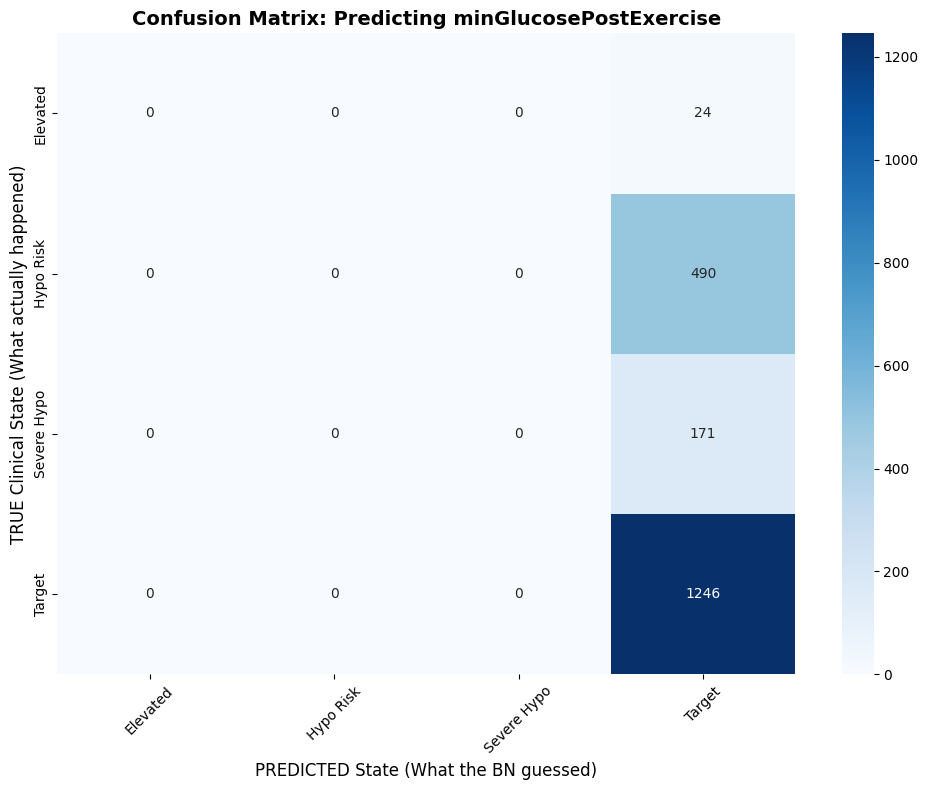

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Setup the Inference Engine
ie = gum.LazyPropagation(tiered_bn_trained)

y_true = []
y_pred = []

predictors = [
    # Static
    'age', 'gender', 'height', 'weight', 'HbA1c', 'InsSensitivity', 'InsCarbRatio',
    # Pre-Exercise
    'preExerciseRoc', 'startExerciseGlucoseLevel', 'preExerciseGlucoseCV', 'IOB', 'COB', 'ACWR',
    # Exercise
    'MET', 'MET_min', 'DurationValue', 'EnergyPerMinute'
]

print(f"Running predictions on {len(test_data_bn)} unseen patient sessions...")

# 2. Iterate through the Test Set
for index, row in test_data_bn.iterrows():
    ie.eraseAllEvidence()
    
    # Build the evidence dictionary for this specific workout session
    evidence = {}
    for predictor in predictors:
        val = str(row[predictor])
        # Safety check: Only add if the state exists in the network's vocabulary
        if val in tiered_bn_trained.variableFromName(predictor).labels():
            evidence[predictor] = val
            
    try:
        # Feed the data into the network
        ie.setEvidence(evidence)
        ie.makeInference()
        
        # Look at the predicted probabilities for the target outcome
        posterior = ie.posterior(target_node).toarray()
        
        # Pick the state with the highest predicted probability
        predicted_idx = np.argmax(posterior)
        predicted_state = tiered_bn_trained.variableFromName(target_node).label(int(predicted_idx))
        
        y_pred.append(predicted_state)
        y_true.append(str(row[target_node]))
        
    except Exception as e:
        # Failsafe for any weird rows
        continue

# 3. Calculate Overall Metrics
acc = accuracy_score(y_true, y_pred)
print(f"\n✅ OVERALL ACCURACY: {acc * 100:.2f}%\n")
print("--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred))

# 4. Draw the Publication-Ready Confusion Matrix
# Get the exact order of states from the network
labels = list(tiered_bn_trained.variableFromName(target_node).labels())

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix: Predicting {target_node}', fontsize=14, fontweight='bold')
plt.ylabel('TRUE Clinical State (What actually happened)', fontsize=12)
plt.xlabel('PREDICTED State (What the BN guessed)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Running Threshold Tuning Predictions...

✅ ACCURACY (With Clinical Thresholds): 50.49%

              precision    recall  f1-score   support

    Elevated       0.00      0.00      0.00        24
   Hypo Risk       0.00      0.00      0.00       490
 Severe Hypo       0.10      0.33      0.16       171
      Target       0.66      0.74      0.70      1246

    accuracy                           0.50      1931
   macro avg       0.19      0.27      0.21      1931
weighted avg       0.43      0.50      0.46      1931



/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


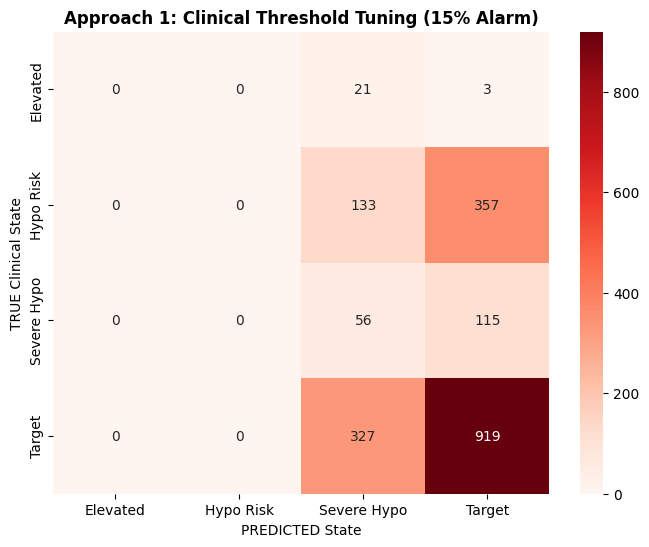

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Setup Inference using your ORIGINAL trained network
ie = gum.LazyPropagation(tiered_bn_trained)
labels = list(tiered_bn_trained.variableFromName(target_node).labels())

# Find the exact index of the Hypo states in the probability array
idx_severe_hypo = labels.index('Severe Hypo')
idx_hypo_risk = labels.index('Hypo Risk')

y_true_thresh = []
y_pred_thresh = []

print("Running Threshold Tuning Predictions...")

for index, row in test_data_bn.iterrows():
    ie.eraseAllEvidence()
    
    evidence = {}
    for predictor in predictors: # Using our strictly safe predictor list
        val = str(row[predictor])
        if val in tiered_bn_trained.variableFromName(predictor).labels():
            evidence[predictor] = val
            
    try:
        ie.setEvidence(evidence)
        ie.makeInference()
        posterior = ie.posterior(target_node).toarray()
        
        # --- THE SMART ALARM LOGIC ---
        prob_severe = posterior[idx_severe_hypo]
        prob_risk = posterior[idx_hypo_risk]
        
        # Rule 1: If Severe Hypo risk >= 15%, override and predict Severe Hypo
        if prob_severe >= 0.1:
            predicted_state = 'Severe Hypo'
        # Rule 2: If general Hypo Risk >= 25%, predict Hypo Risk
        elif prob_risk >= 0.25:
            predicted_state = 'Hypo Risk'
        # Default: Otherwise, just pick the mathematically highest probability
        else:
            predicted_idx = np.argmax(posterior)
            predicted_state = labels[int(predicted_idx)]
            
        y_pred_thresh.append(predicted_state)
        y_true_thresh.append(str(row[target_node]))
        
    except Exception as e:
        continue

# Metrics & Matrix
print(f"\n✅ ACCURACY (With Clinical Thresholds): {accuracy_score(y_true_thresh, y_pred_thresh) * 100:.2f}%\n")
print(classification_report(y_true_thresh, y_pred_thresh))

cm = confusion_matrix(y_true_thresh, y_pred_thresh, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
plt.title('Approach 1: Clinical Threshold Tuning (15% Alarm)', fontweight='bold')
plt.ylabel('TRUE Clinical State')
plt.xlabel('PREDICTED State')
plt.show()

Balancing the training data...
New perfectly balanced training priors:
minGlucosePostExercise
Target         2525
Hypo Risk      2525
Severe Hypo    2525
Elevated       2525
Name: count, dtype: int64
Balanced network trained successfully!
Running Predictions on Unseen Test Set...

✅ ACCURACY (Balanced Training Data): 27.60%

              precision    recall  f1-score   support

    Elevated       0.04      0.17      0.06        24
   Hypo Risk       0.28      0.77      0.41       490
 Severe Hypo       0.11      0.20      0.15       171
      Target       0.70      0.10      0.17      1246

    accuracy                           0.28      1931
   macro avg       0.28      0.31      0.20      1931
weighted avg       0.53      0.28      0.23      1931



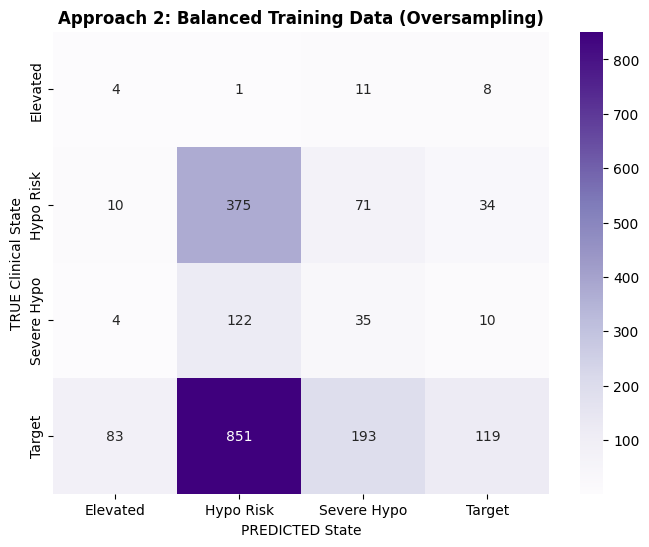

In [7]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd

# --- PART A: BALANCE THE TRAINING DATA ---
print("Balancing the training data...")
X_train = train_data_bn.drop(columns=[target_node])
y_train = train_data_bn[target_node]

# Oversample so all classes match the size of the majority class ('Target')
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

# Recombine
train_data_balanced = pd.concat([X_resampled, y_resampled], axis=1)
print("New perfectly balanced training priors:")
print(train_data_balanced[target_node].value_counts())

# --- PART B: TRAIN THE NEW BALANCED NETWORK ---
learner_balanced = gum.BNLearner(train_data_balanced)
learner_balanced.useGreedyHillClimbing()

learner_balanced = apply_clinical_constraints(learner_balanced)

tiered_bn_balanced = learner_balanced.learnBN()
print("Balanced network trained successfully!")

# --- PART C: TEST THE BALANCED NETWORK (Standard argmax) ---
ie_balanced = gum.LazyPropagation(tiered_bn_balanced)

y_true_bal = []
y_pred_bal = []

print("Running Predictions on Unseen Test Set...")

for index, row in test_data_bn.iterrows():
    ie_balanced.eraseAllEvidence()
    
    evidence = {}
    for predictor in predictors:
        val = str(row[predictor])
        if val in tiered_bn_balanced.variableFromName(predictor).labels():
            evidence[predictor] = val
            
    try:
        ie_balanced.setEvidence(evidence)
        ie_balanced.makeInference()
        posterior = ie_balanced.posterior(target_node).toarray()
        
        # Because the priors are balanced, we can safely use normal argmax!
        predicted_idx = np.argmax(posterior)
        predicted_state = labels[int(predicted_idx)]
            
        y_pred_bal.append(predicted_state)
        y_true_bal.append(str(row[target_node]))
        
    except Exception as e:
        continue

# Metrics & Matrix
print(f"\n✅ ACCURACY (Balanced Training Data): {accuracy_score(y_true_bal, y_pred_bal) * 100:.2f}%\n")
print(classification_report(y_true_bal, y_pred_bal))

cm_bal = confusion_matrix(y_true_bal, y_pred_bal, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.title('Approach 2: Balanced Training Data (Oversampling)', fontweight='bold')
plt.ylabel('TRUE Clinical State')
plt.xlabel('PREDICTED State')
plt.show()

Calculating Information Theory metrics...


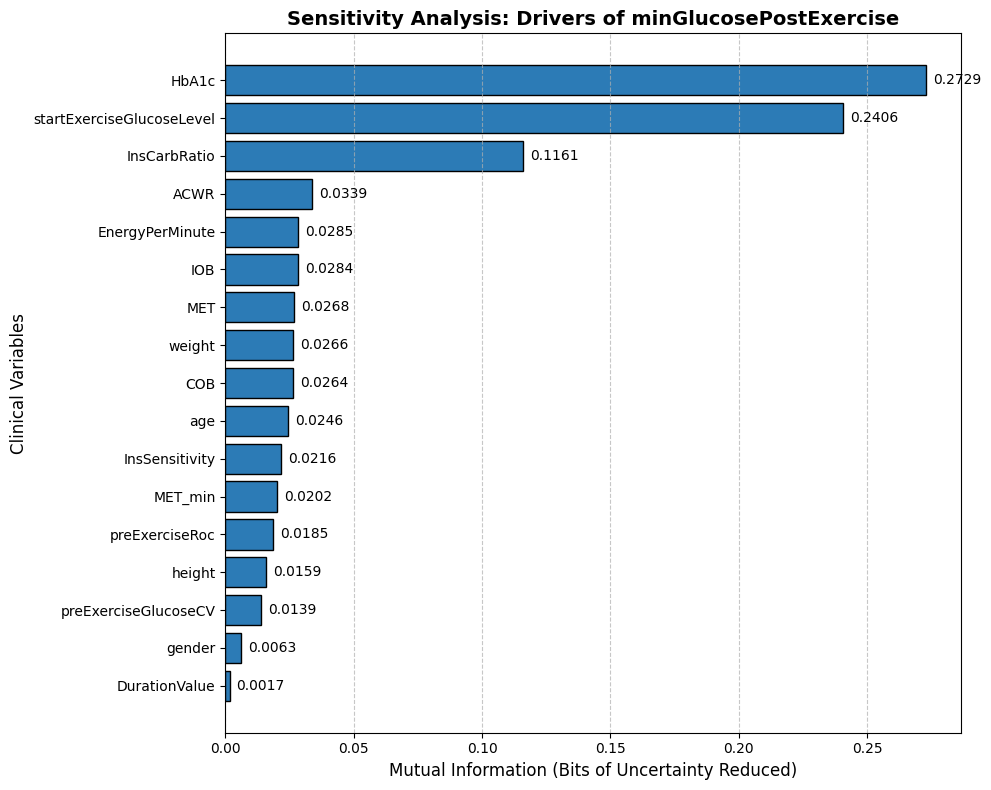

In [8]:
import pyagrum as gum
import matplotlib.pyplot as plt
import numpy as np


# 1. Initialize the Inference Engine with your balanced network
ie_balanced = gum.LazyPropagation(tiered_bn_balanced)

# 2. Use our explicitly safe list of predictors (No simultaneous outcomes!)
predictors = [
    # Static
    'age', 'gender', 'height', 'weight', 'HbA1c', 'InsSensitivity', 'InsCarbRatio',
    # Pre-Exercise
    'preExerciseRoc', 'startExerciseGlucoseLevel', 'preExerciseGlucoseCV', 'IOB', 'COB', 'ACWR',
    # Exercise
    'MET', 'MET_min', 'DurationValue', 'EnergyPerMinute'
]

mi_results = {}

print("Calculating Information Theory metrics...")

for node in predictors:
    try:
        # 3. Initialize the Information Theory object FOR EACH PAIR
        it = gum.InformationTheory(ie_balanced, target_node, node)
        
        # Extract the Mutual Information
        mi = it.mutualInformationXY()
        mi_results[node] = mi
    except Exception as e:
        print(f"Skipping {node} due to optimization: {e}")
        continue

# 4. Sort the results from lowest to highest
sorted_mi = sorted(mi_results.items(), key=lambda item: item[1], reverse=False) 
features = [item[0] for item in sorted_mi]
scores = [item[1] for item in sorted_mi]

# 5. Draw the Publication-Ready Tornado Diagram
plt.figure(figsize=(10, 8))
bars = plt.barh(features, scores, color='#2c7bb6', edgecolor='black')

plt.title(f'Sensitivity Analysis: Drivers of {target_node}', fontsize=14, fontweight='bold')
plt.xlabel('Mutual Information (Bits of Uncertainty Reduced)', fontsize=12)
plt.ylabel('Clinical Variables', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add the exact numerical values to the end of each bar
for bar in bars:
    width = bar.get_width()
    if width > 0.0001: 
        plt.text(width + max(scores)*0.01, bar.get_y() + bar.get_height()/2, 
                 f'{width:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()